<a href="https://colab.research.google.com/github/Fahad43215/viscosity-with-and-without-zealots/blob/main/STAG%20HUNT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Unstable threshold x* = 0.8333


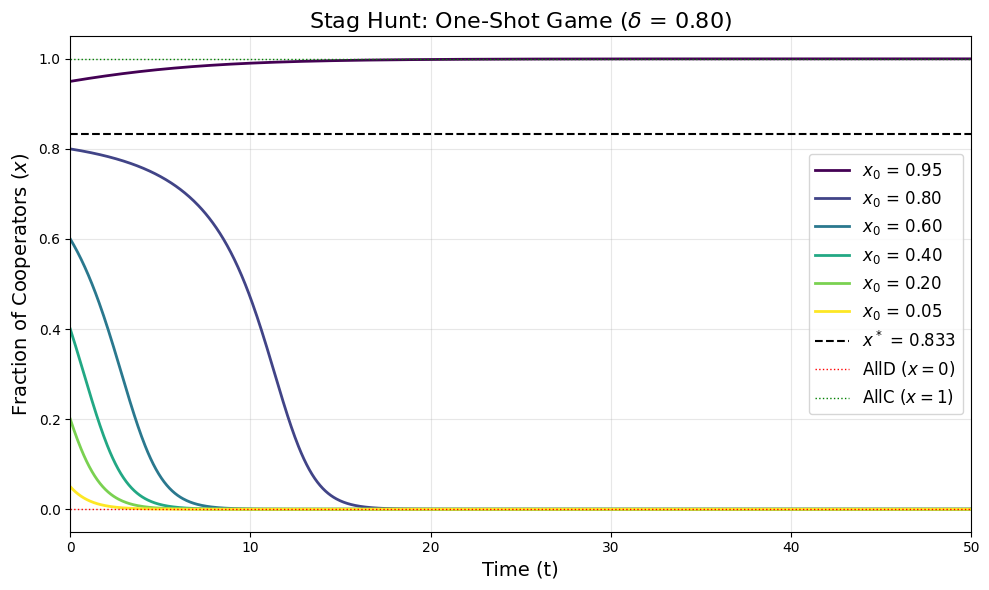

In [1]:
# =========================================================
# STAG HUNT GAME - TIME SERIES (No Viscosity, No Zealots)
# Payoff Matrix:
#            C       D
#   C   [   1      -1   ]
#   D   [   delta    0   ]
#
# Replicator Equation:
#   dx/dt = x(1-x) * [ (2 - delta)*x - 1 ]
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ---------- PARAMETERS ----------
delta = 0.8          # Temptation payoff (0 < delta < 1)
                     # For Stag Hunt, delta must be between 0 and 1.

# Unstable threshold: x* = 1 / (2 - delta)
x_star = 1 / (2 - delta)
print(f'Unstable threshold x* = {x_star:.4f}')

# ---------- ODE FUNCTION ----------
def stag_hunt_dynamics(x, t, delta):
    """
    Replicator dynamics for Stag Hunt:
        dx/dt = x*(1-x)*((2-delta)*x - 1)
    """
    return x * (1 - x) * ((2 - delta) * x - 1)

# ---------- TIME SPAN ----------
tspan = np.linspace(0, 50, 1000)   # Simulate from t=0 to t=50

# ---------- INITIAL CONDITIONS ----------
x0_list = [0.95, 0.80, 0.60, 0.40, 0.20, 0.05]

# ---------- SOLVE & PLOT ----------
plt.figure(figsize=(10, 6))

# Color map for different trajectories
colors = plt.cm.viridis(np.linspace(0, 1, len(x0_list)))

for i, x0 in enumerate(x0_list):
    sol = odeint(stag_hunt_dynamics, x0, tspan, args=(delta,))
    plt.plot(tspan, sol, linewidth=2, color=colors[i],
             label=f'$x_0$ = {x0:.2f}')

# Mark the unstable threshold as a dashed horizontal line
plt.axhline(y=x_star, color='k', linestyle='--', linewidth=1.5,
            label=f'$x^*$ = {x_star:.3f}')

# Mark the stable equilibria
plt.axhline(y=0, color='r', linestyle=':', linewidth=1, label='AllD ($x=0$)')
plt.axhline(y=1, color='g', linestyle=':', linewidth=1, label='AllC ($x=1$)')

plt.xlabel('Time (t)', fontsize=14)
plt.ylabel('Fraction of Cooperators ($x$)', fontsize=14)
plt.title(f'Stag Hunt: One-Shot Game ($\\delta$ = {delta:.2f})', fontsize=16)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, tspan[-1])
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()


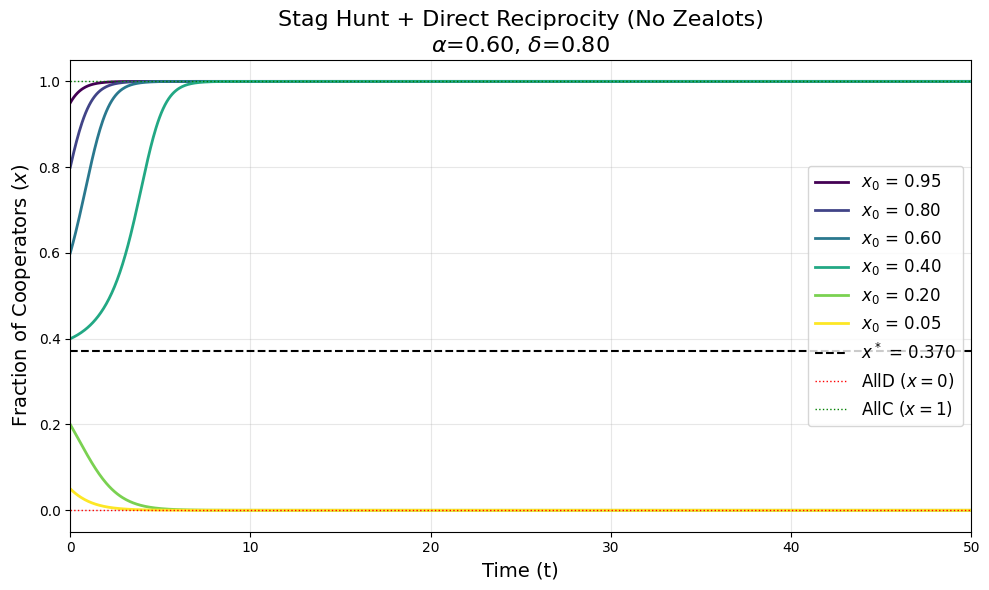

In [2]:
# =========================================================
# STAG HUNT + DIRECT RECIPROCITY - WITHOUT ZEALOTS
#
# Effective Payoff Matrix:
#            C          D
#   C   [  1/(1-α)     -1   ]
#   D   [    δ          0   ]
#
# Replicator Equation:
#   dx/dt = x(1-x) * [ -1 + x*( 1/(1-α) + 1 - δ ) ]
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ---------- PARAMETERS ----------
alpha = 0.6          # Continuation probability (0 <= alpha <= 1)
delta = 0.8          # Temptation payoff (0 < delta < 1)

# Effective payoffs
R_tilde = 1 / (1 - alpha)
S_tilde = -1
T_tilde = delta
P_tilde = 0

# ---------- ODE FUNCTION ----------
def stag_hunt_dr_no_zealot(x, t, alpha, delta):
    """
    Replicator dynamics for Stag Hunt + Direct Reciprocity (no zealots):
        dx/dt = x(1-x) * [ -1 + x*( 1/(1-α) + 1 - δ ) ]
    """
    R_tilde = 1 / (1 - alpha)
    fitness_diff = -1 + x * (R_tilde + 1 - delta)
    return x * (1 - x) * fitness_diff

# ---------- TIME SPAN ----------
tspan = np.linspace(0, 50, 1000)

# ---------- INITIAL CONDITIONS ----------
x0_list = [0.95, 0.80, 0.60, 0.40, 0.20, 0.05]

# ---------- SOLVE & PLOT ----------
plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(x0_list)))

for i, x0 in enumerate(x0_list):
    sol = odeint(stag_hunt_dr_no_zealot, x0, tspan, args=(alpha, delta))
    plt.plot(tspan, sol, linewidth=2, color=colors[i],
             label=f'$x_0$ = {x0:.2f}')

# Find and mark the unstable threshold (if it exists in [0,1])
# Solve: -1 + x*(R_tilde + 1 - delta) = 0
R_tilde = 1 / (1 - alpha)
x_star = 1 / (R_tilde + 1 - delta)
if 0 < x_star < 1:
    plt.axhline(y=x_star, color='k', linestyle='--', linewidth=1.5,
                label=f'$x^*$ = {x_star:.3f}')

plt.axhline(y=0, color='r', linestyle=':', linewidth=1, label='AllD ($x=0$)')
plt.axhline(y=1, color='g', linestyle=':', linewidth=1, label='AllC ($x=1$)')

plt.xlabel('Time (t)', fontsize=14)
plt.ylabel('Fraction of Cooperators ($x$)', fontsize=14)
plt.title(f'Stag Hunt + Direct Reciprocity (No Zealots)\n$\\alpha$={alpha:.2f}, $\\delta$={delta:.2f}', fontsize=16)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, tspan[-1])
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

/tmp/ipykernel_730/3522350597.py:55: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(stag_hunt_dr_zealot_C, x0, tspan, args=(alpha, delta, yc))


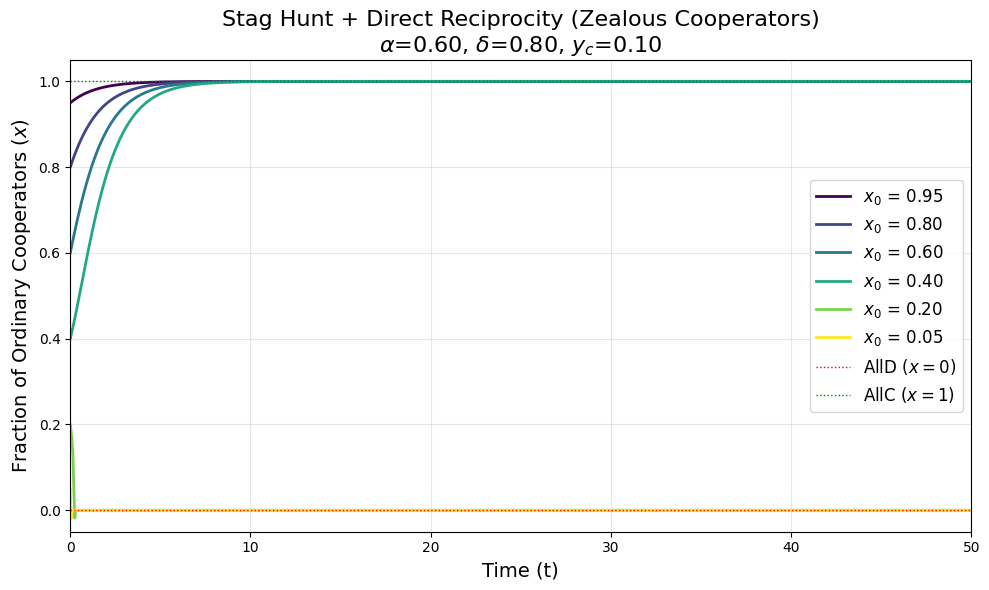

In [3]:
# =========================================================
# STAG HUNT + DIRECT RECIPROCITY - WITH ZEALOUS COOPERATORS
#
# Effective Payoff Matrix:
#            C          D
#   C   [  1/(1-α)     -1   ]
#   D   [    δ          0   ]
#
# Zealous Cooperator Dynamics (after canceling <π>):
#   dx/dt = (1-x) * [ (x+yc)*R_tilde - 1 + x*(1-δ) ]
#           -----------------------------------------
#           (x+yc)*R_tilde + (1-x)*(δ-1)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ---------- PARAMETERS ----------
alpha = 0.6          # Continuation probability (0 <= alpha <= 1)
delta = 0.8          # Temptation payoff (0 < delta < 1)
yc = 0.1             # Fraction of zealous cooperators

# Effective payoffs
R_tilde = 1 / (1 - alpha)

# ---------- ODE FUNCTION ----------
def stag_hunt_dr_zealot_C(x, t, alpha, delta, yc):
    """
    Zealous cooperator dynamics for Stag Hunt + Direct Reciprocity:
        dx/dt = (1-x) * [ (x+yc)*R_tilde - 1 + x*(1-δ) ]
                -----------------------------------------
                (x+yc)*R_tilde + (1-x)*(δ-1)
    """
    R_tilde = 1 / (1 - alpha)

    numerator = (1 - x) * ((x + yc) * R_tilde - 1 + x * (1 - delta))
    denominator = (x + yc) * R_tilde + (1 - x) * (delta - 1)

    # Avoid division by zero (denominator is always positive for valid params)
    return numerator / denominator

# ---------- TIME SPAN ----------
tspan = np.linspace(0, 50, 1000)

# ---------- INITIAL CONDITIONS ----------
x0_list = [0.95, 0.80, 0.60, 0.40, 0.20, 0.05]

# ---------- SOLVE & PLOT ----------
plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(x0_list)))

for i, x0 in enumerate(x0_list):
    sol = odeint(stag_hunt_dr_zealot_C, x0, tspan, args=(alpha, delta, yc))
    plt.plot(tspan, sol, linewidth=2, color=colors[i],
             label=f'$x_0$ = {x0:.2f}')

plt.axhline(y=0, color='r', linestyle=':', linewidth=1, label='AllD ($x=0$)')
plt.axhline(y=1, color='g', linestyle=':', linewidth=1, label='AllC ($x=1$)')

plt.xlabel('Time (t)', fontsize=14)
plt.ylabel('Fraction of Ordinary Cooperators ($x$)', fontsize=14)
plt.title(f'Stag Hunt + Direct Reciprocity (Zealous Cooperators)\n$\\alpha$={alpha:.2f}, $\\delta$={delta:.2f}, $y_c$={yc:.2f}', fontsize=16)
plt.legend(loc='best', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, tspan[-1])
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

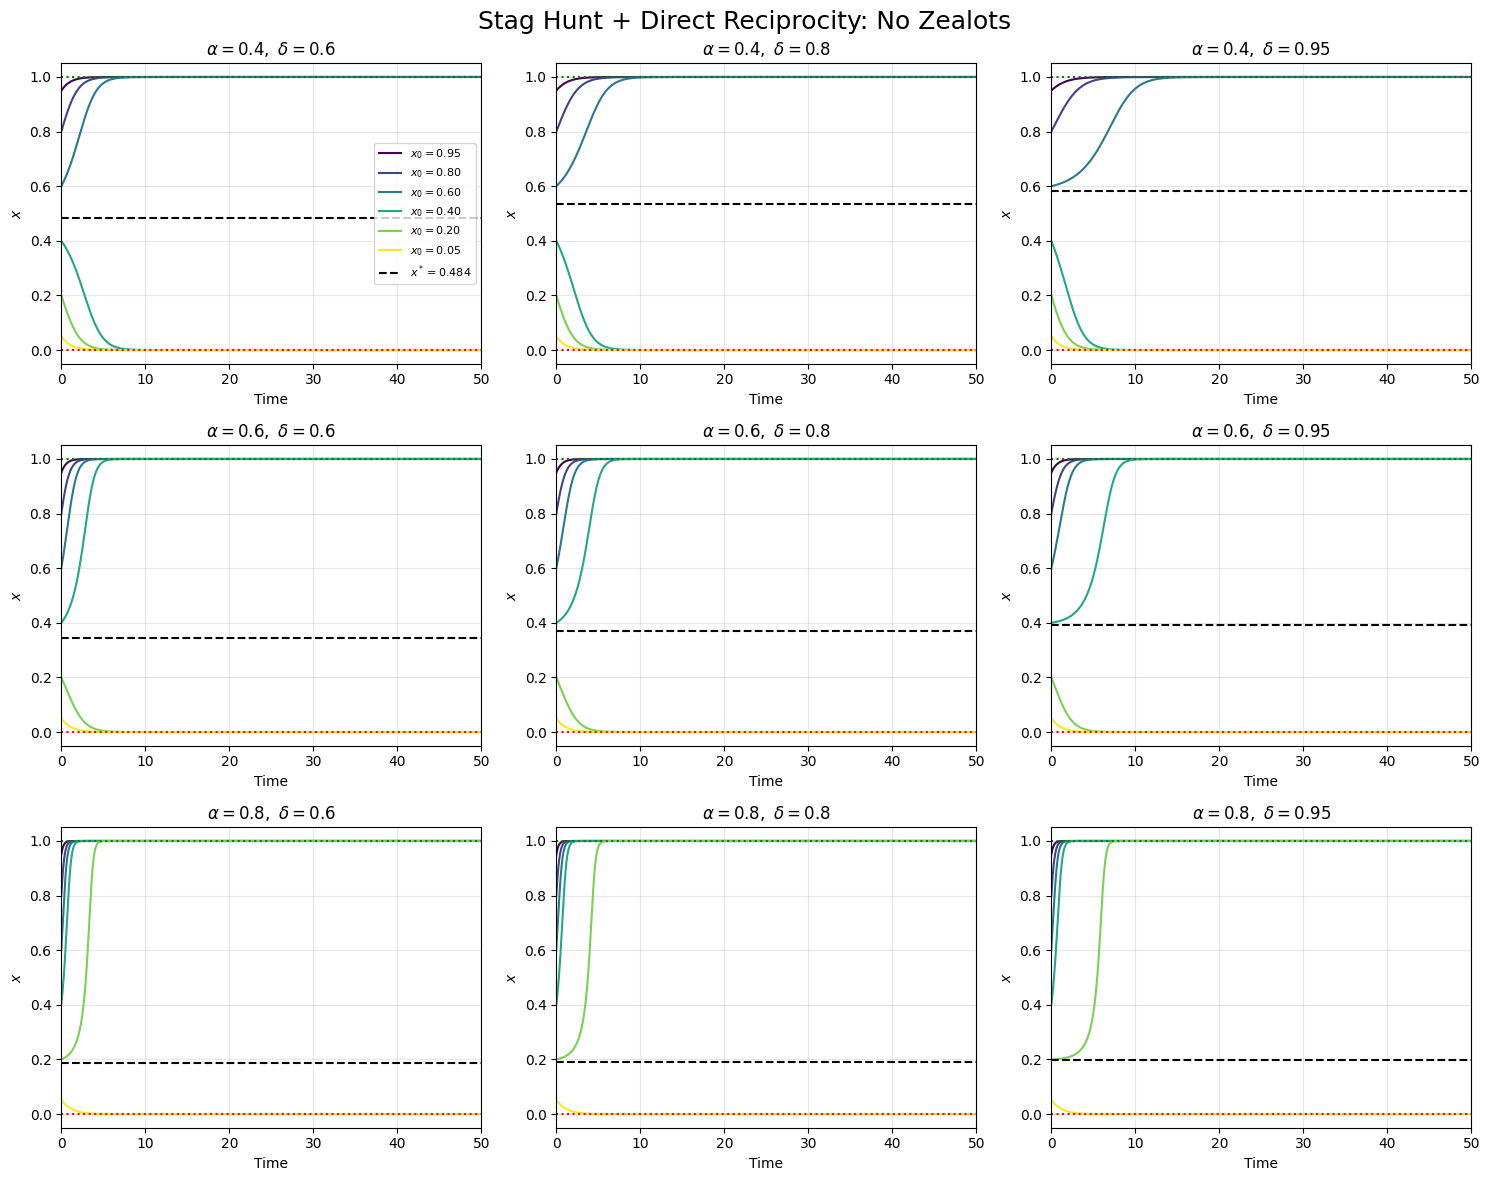

/tmp/ipykernel_730/2347687570.py:106: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  sol = odeint(
/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_base.py:3024: RuntimeWarning: overflow encountered in scalar subtract
  x0, x1 = inverse_trans.transform([x0t - delta, x1t + delta])


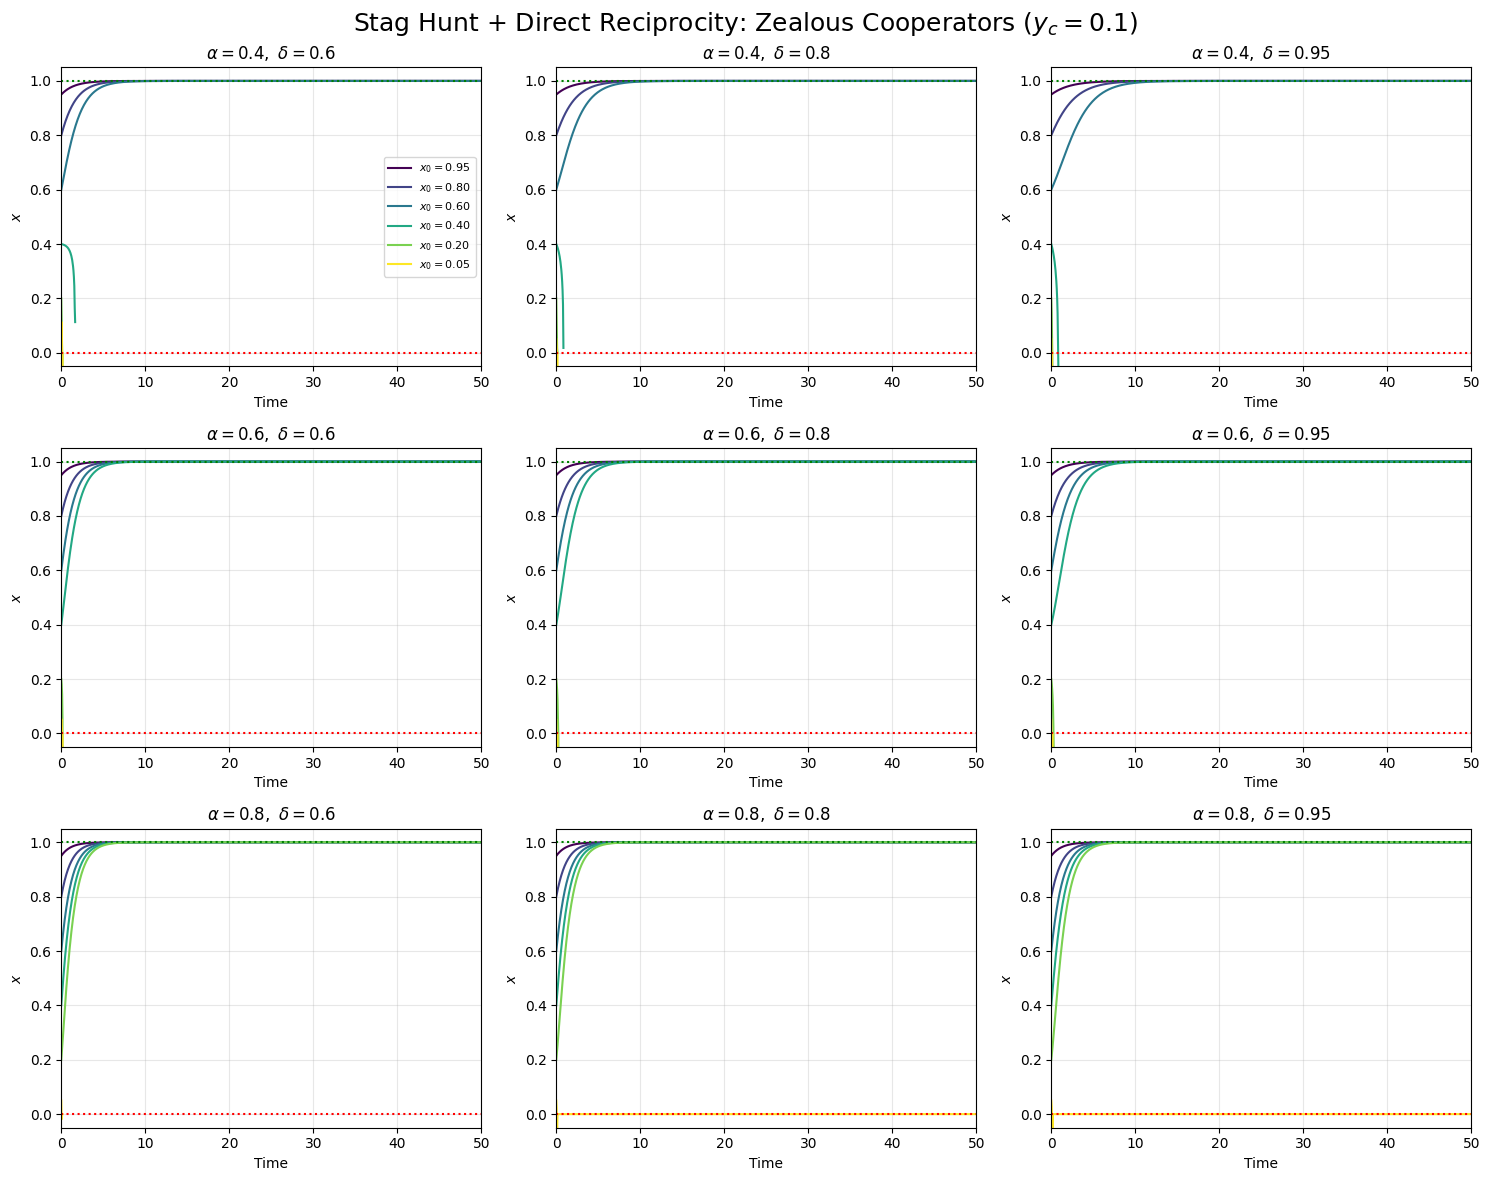


===== PARAMETER SUMMARY =====
Zealous cooperators yc = 0.1
alpha values = [0.4, 0.6, 0.8]
delta values = [0.6, 0.8, 0.95]

Interior equilibrium (No Zealots):
alpha=0.4, delta=0.60 -> x* = 0.4839
alpha=0.4, delta=0.80 -> x* = 0.5357
alpha=0.4, delta=0.95 -> x* = 0.5825
alpha=0.6, delta=0.60 -> x* = 0.3448
alpha=0.6, delta=0.80 -> x* = 0.3704
alpha=0.6, delta=0.95 -> x* = 0.3922
alpha=0.8, delta=0.60 -> x* = 0.1852
alpha=0.8, delta=0.80 -> x* = 0.1923
alpha=0.8, delta=0.95 -> x* = 0.1980


In [6]:
# ---------- PARAMETERS ----------
alpha_values = [0.4, 0.6, 0.8]
delta_values = [0.6, 0.8, 0.95]
yc = 0.1

# ---------- INITIAL CONDITIONS ----------
x0_list = [0.95, 0.80, 0.60, 0.40, 0.20, 0.05]

# ---------- TIME ----------
tspan = np.linspace(0, 50, 1000)

# =========================================================
# ODE FUNCTIONS
# =========================================================

def no_zealot(x, t, alpha, delta):
    R_tilde = 1/(1-alpha)
    return x*(1-x)*(-1 + x*(R_tilde + 1 - delta))


def zealot_C(x, t, alpha, delta, yc):
    R_tilde = 1/(1-alpha)

    numerator = (1-x)*((x+yc)*R_tilde - 1 + x*(1-delta))
    denominator = (x+yc)*R_tilde + (1-x)*(delta-1)

    return numerator/denominator


# =========================================================
# 1. NO ZEALOTS
# =========================================================

fig1, axes1 = plt.subplots(3,3,figsize=(15,12))
fig1.suptitle("Stag Hunt + Direct Reciprocity: No Zealots",
              fontsize=18)

colors = plt.cm.viridis(np.linspace(0,1,len(x0_list)))

for i, alpha in enumerate(alpha_values):

    for j, delta in enumerate(delta_values):

        ax = axes1[i,j]

        R_tilde = 1/(1-alpha)

        for k,x0 in enumerate(x0_list):

            sol = odeint(no_zealot,x0,tspan,args=(alpha,delta))

            ax.plot(
                tspan,
                sol,
                color=colors[k],
                lw=1.5,
                label=f"$x_0={x0:.2f}$"
            )

        x_star = 1/(R_tilde+1-delta)

        if 0<x_star<1:
            ax.axhline(
                x_star,
                color='k',
                ls='--',
                lw=1.5,
                label=f"$x^*={x_star:.3f}$"
            )

        ax.axhline(0,color='r',ls=':')
        ax.axhline(1,color='g',ls=':')

        ax.set_title(fr"$\alpha={alpha},\ \delta={delta}$")
        ax.set_xlim(0,50)
        ax.set_ylim(-0.05,1.05)
        ax.set_xlabel("Time")
        ax.set_ylabel("$x$")
        ax.grid(alpha=0.3)

        if i==0 and j==0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# =========================================================
# 2. ZEALOUS COOPERATORS
# =========================================================

fig2, axes2 = plt.subplots(3,3,figsize=(15,12))
fig2.suptitle(
    f"Stag Hunt + Direct Reciprocity: Zealous Cooperators ($y_c={yc}$)",
    fontsize=18
)

for i, alpha in enumerate(alpha_values):

    for j, delta in enumerate(delta_values):

        ax = axes2[i,j]

        for k,x0 in enumerate(x0_list):

            sol = odeint(
                zealot_C,
                x0,
                tspan,
                args=(alpha,delta,yc)
            )

            ax.plot(
                tspan,
                sol,
                color=colors[k],
                lw=1.5,
                label=f"$x_0={x0:.2f}$"
            )

        ax.axhline(0,color='r',ls=':')
        ax.axhline(1,color='g',ls=':')

        ax.set_title(fr"$\alpha={alpha},\ \delta={delta}$")
        ax.set_xlim(0,50)
        ax.set_ylim(-0.05,1.05)
        ax.set_xlabel("Time")
        ax.set_ylabel("$x$")
        ax.grid(alpha=0.3)

        if i==0 and j==0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# =========================================================
# PARAMETER SUMMARY
# =========================================================

print("\n===== PARAMETER SUMMARY =====")
print(f"Zealous cooperators yc = {yc}")
print(f"alpha values = {alpha_values}")
print(f"delta values = {delta_values}")

print("\nInterior equilibrium (No Zealots):")

for alpha in alpha_values:

    R_tilde = 1/(1-alpha)

    for delta in delta_values:

        x_star = 1/(R_tilde+1-delta)

        print(
            f"alpha={alpha:.1f}, delta={delta:.2f} -> x* = {x_star:.4f}"
        )

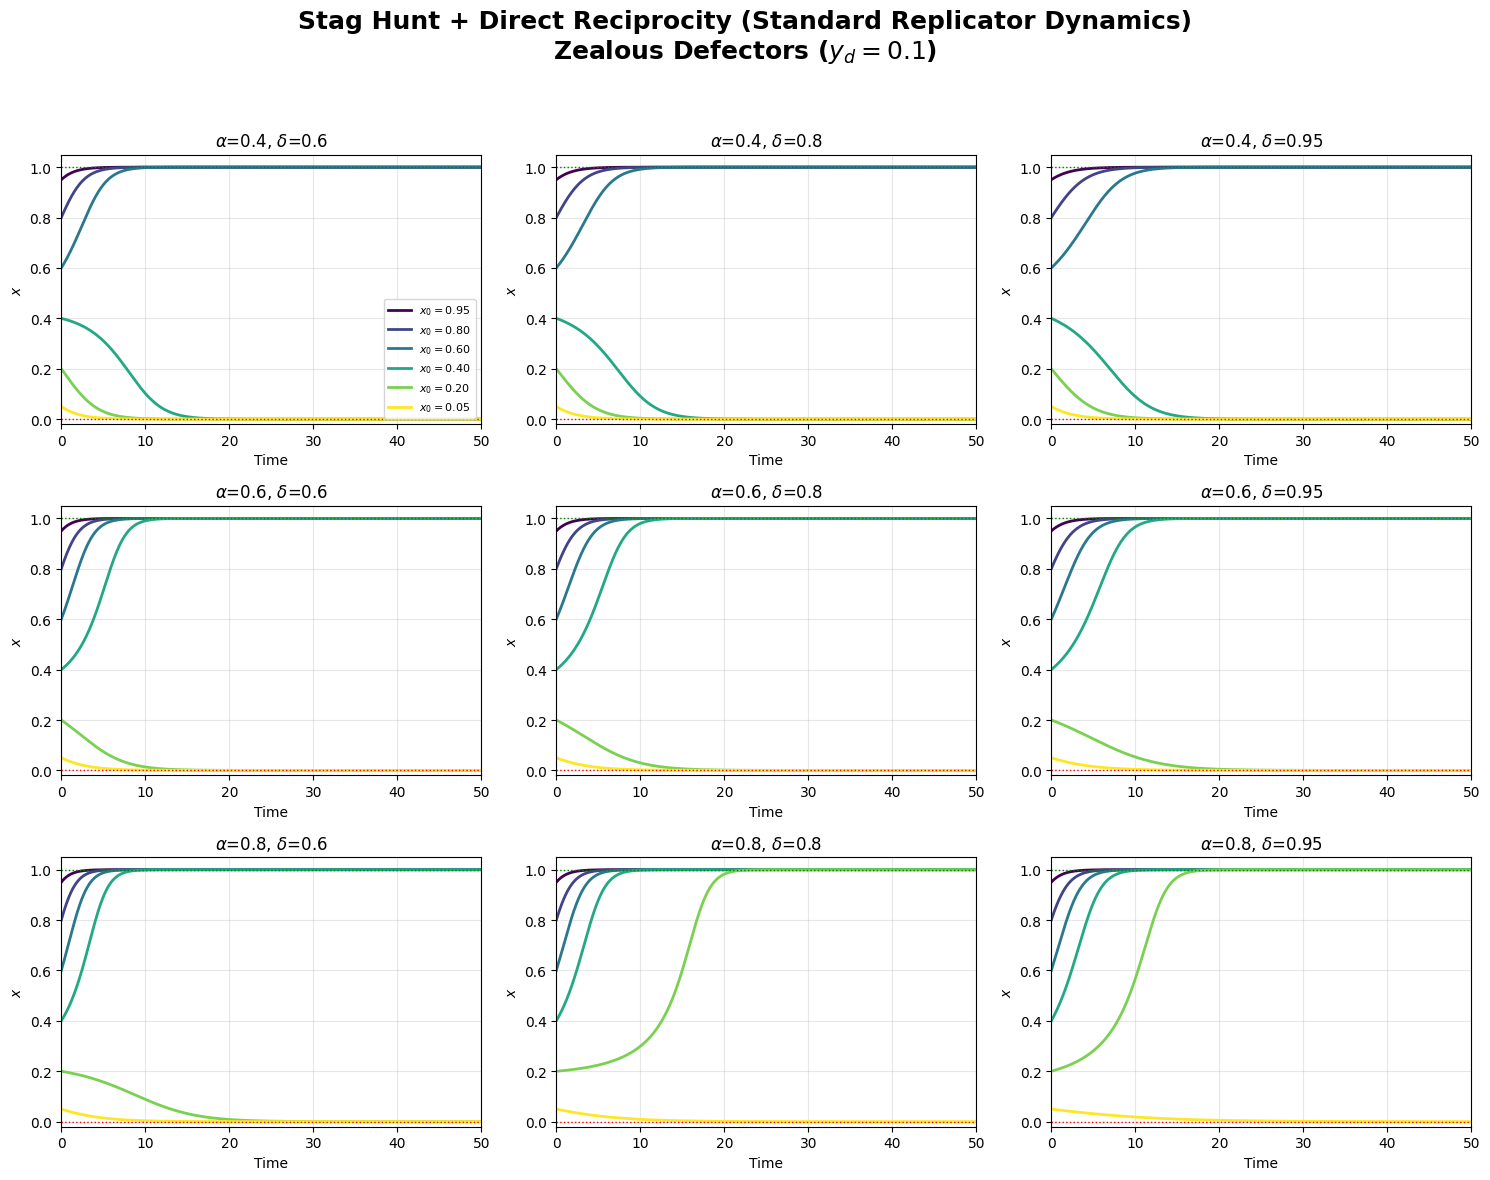

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# STAG HUNT + DIRECT RECIPROCITY
# STANDARD REPLICATOR DYNAMICS (WITHOUT NORMALIZATION)
#
# dx/dt = x(1-x)(piC-piD)
#
# Zealous Defectors
# ============================================================

# Parameters
yd = 0.10

alpha_values = [0.4, 0.6, 0.8]
delta_values = [0.6, 0.8, 0.95]

x0_list = [0.95, 0.80, 0.60, 0.40, 0.20, 0.05]

t_span = (0, 50)
t_eval = np.linspace(0, 50, 1000)

colors = plt.cm.viridis(np.linspace(0, 1, len(x0_list)))

# -------------------------------------------------------------
# Standard Replicator Equation
# -------------------------------------------------------------
def replicator(t, y, alpha, delta, yd):

    x = y[0]

    # Effective payoffs
    R = 1.0
    S = (alpha * delta - 1) / (1 + alpha)
    T = (delta - alpha) / (1 + alpha)
    P = 0.0

    # Fitnesses
    piC = (x * R + (1 - x + yd) * S) / (1 + yd)
    piD = (x * T + (1 - x + yd) * P) / (1 + yd)

    dx = x * (1 - x) * (piC - piD)

    return [dx]

# -------------------------------------------------------------
# Plot
# -------------------------------------------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, alpha in enumerate(alpha_values):

    for j, delta in enumerate(delta_values):

        ax = axes[i, j]

        for k, x0 in enumerate(x0_list):

            sol = solve_ivp(
                replicator,
                t_span,
                [x0],
                args=(alpha, delta, yd),
                t_eval=t_eval,
                rtol=1e-9,
                atol=1e-12
            )

            ax.plot(
                sol.t,
                sol.y[0],
                lw=2,
                color=colors[k],
                label=fr"$x_0={x0:.2f}$"
            )

        ax.axhline(0, color='red', ls=':', lw=1)
        ax.axhline(1, color='green', ls=':', lw=1)

        ax.set_xlim(0, 50)
        ax.set_ylim(-0.02, 1.05)

        ax.set_title(
            fr"$\alpha$={alpha}, $\delta$={delta}",
            fontsize=12
        )

        ax.set_xlabel("Time")
        ax.set_ylabel("$x$")
        ax.grid(alpha=0.3)

        if i == 0 and j == 0:
            ax.legend(fontsize=8)

plt.suptitle(
    "Stag Hunt + Direct Reciprocity (Standard Replicator Dynamics)\n"
    "Zealous Defectors ($y_d=0.1$)",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

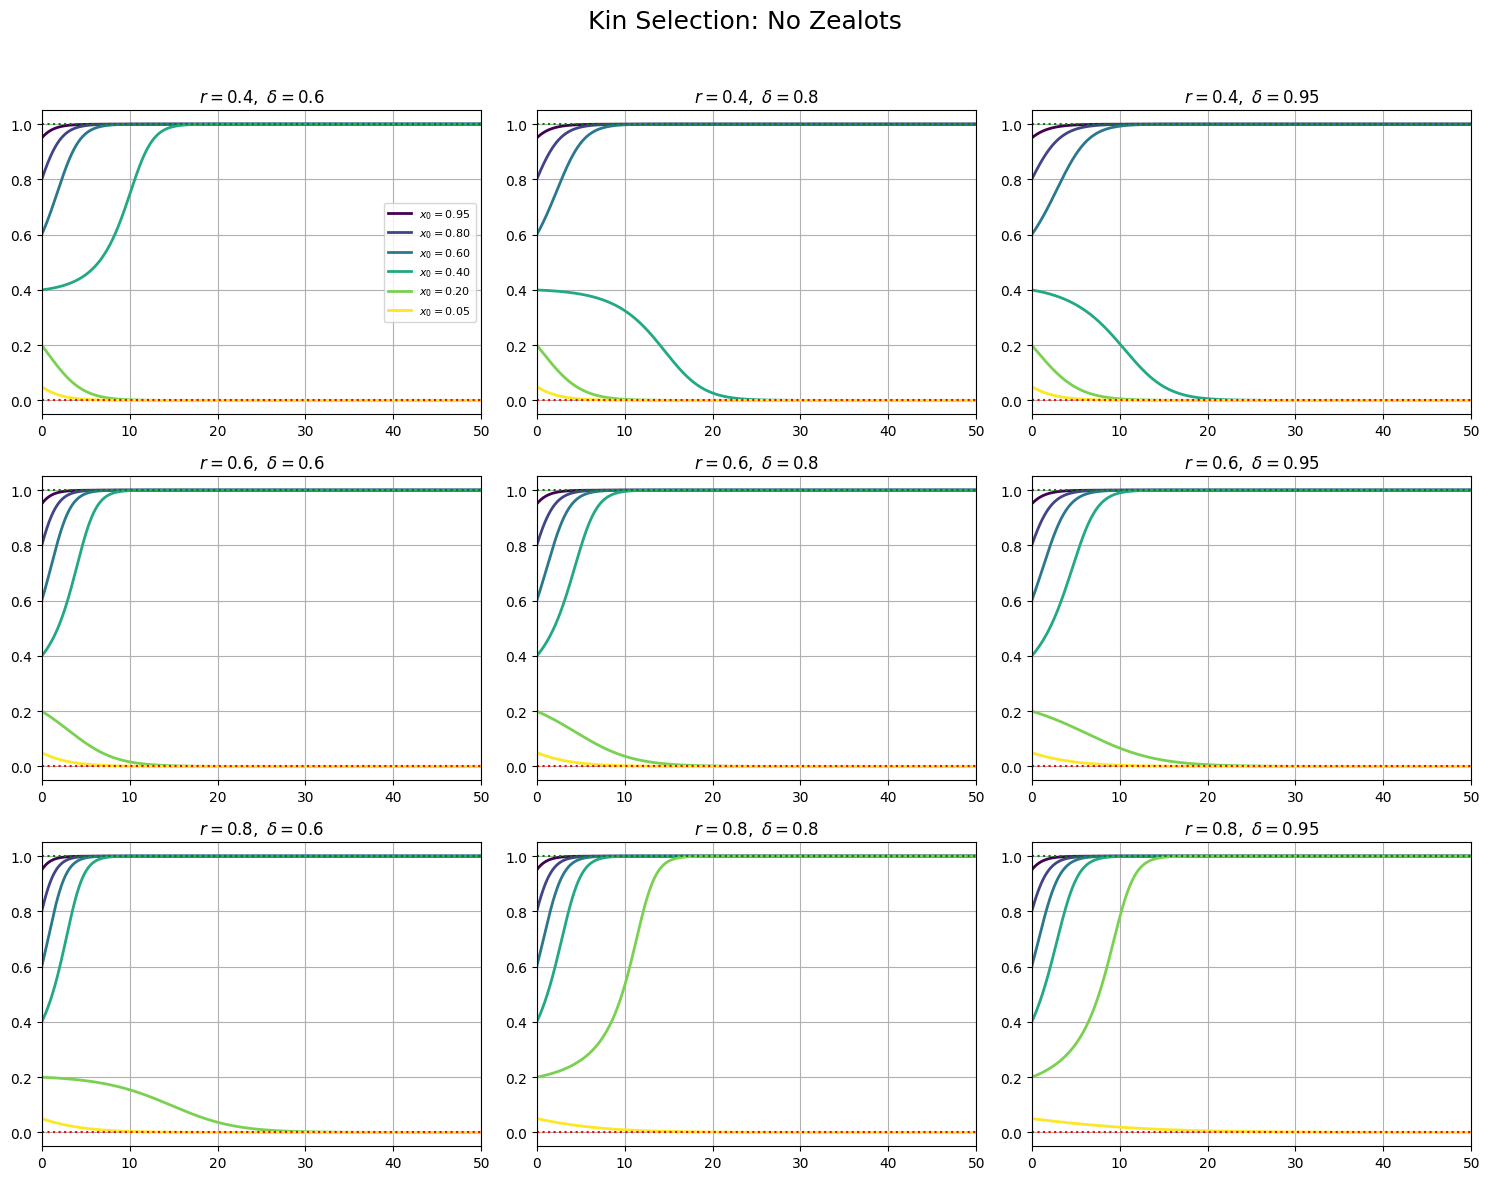

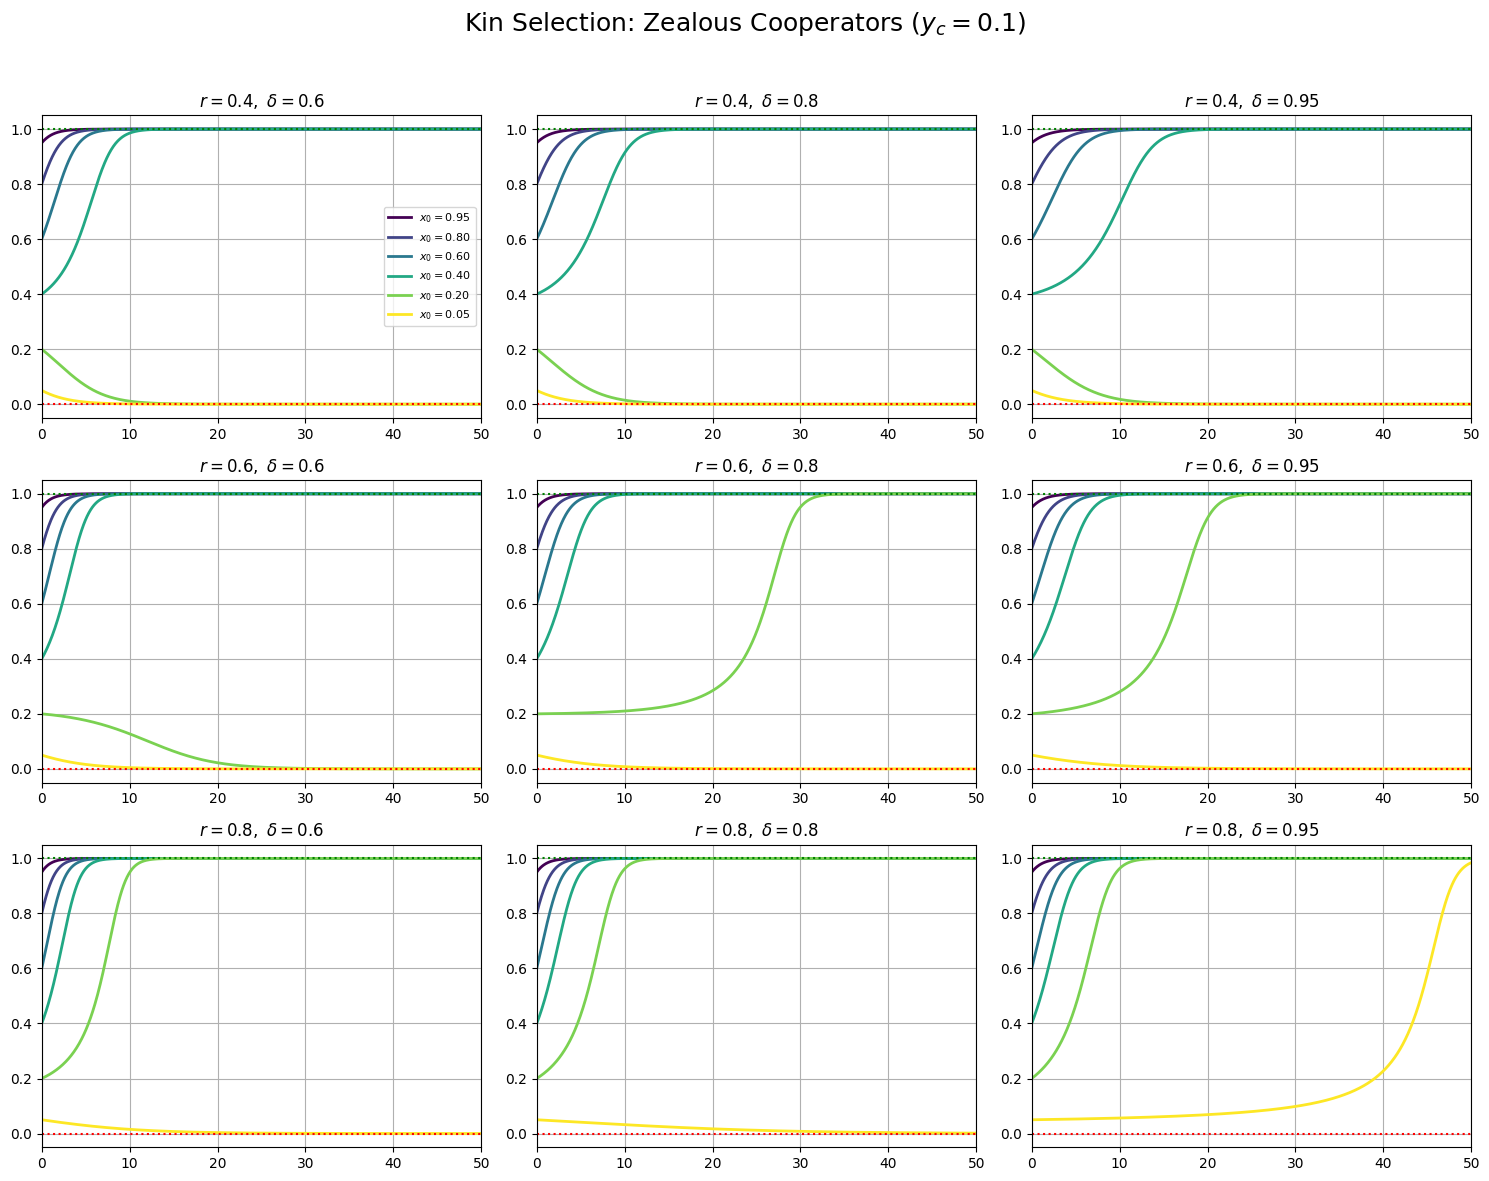

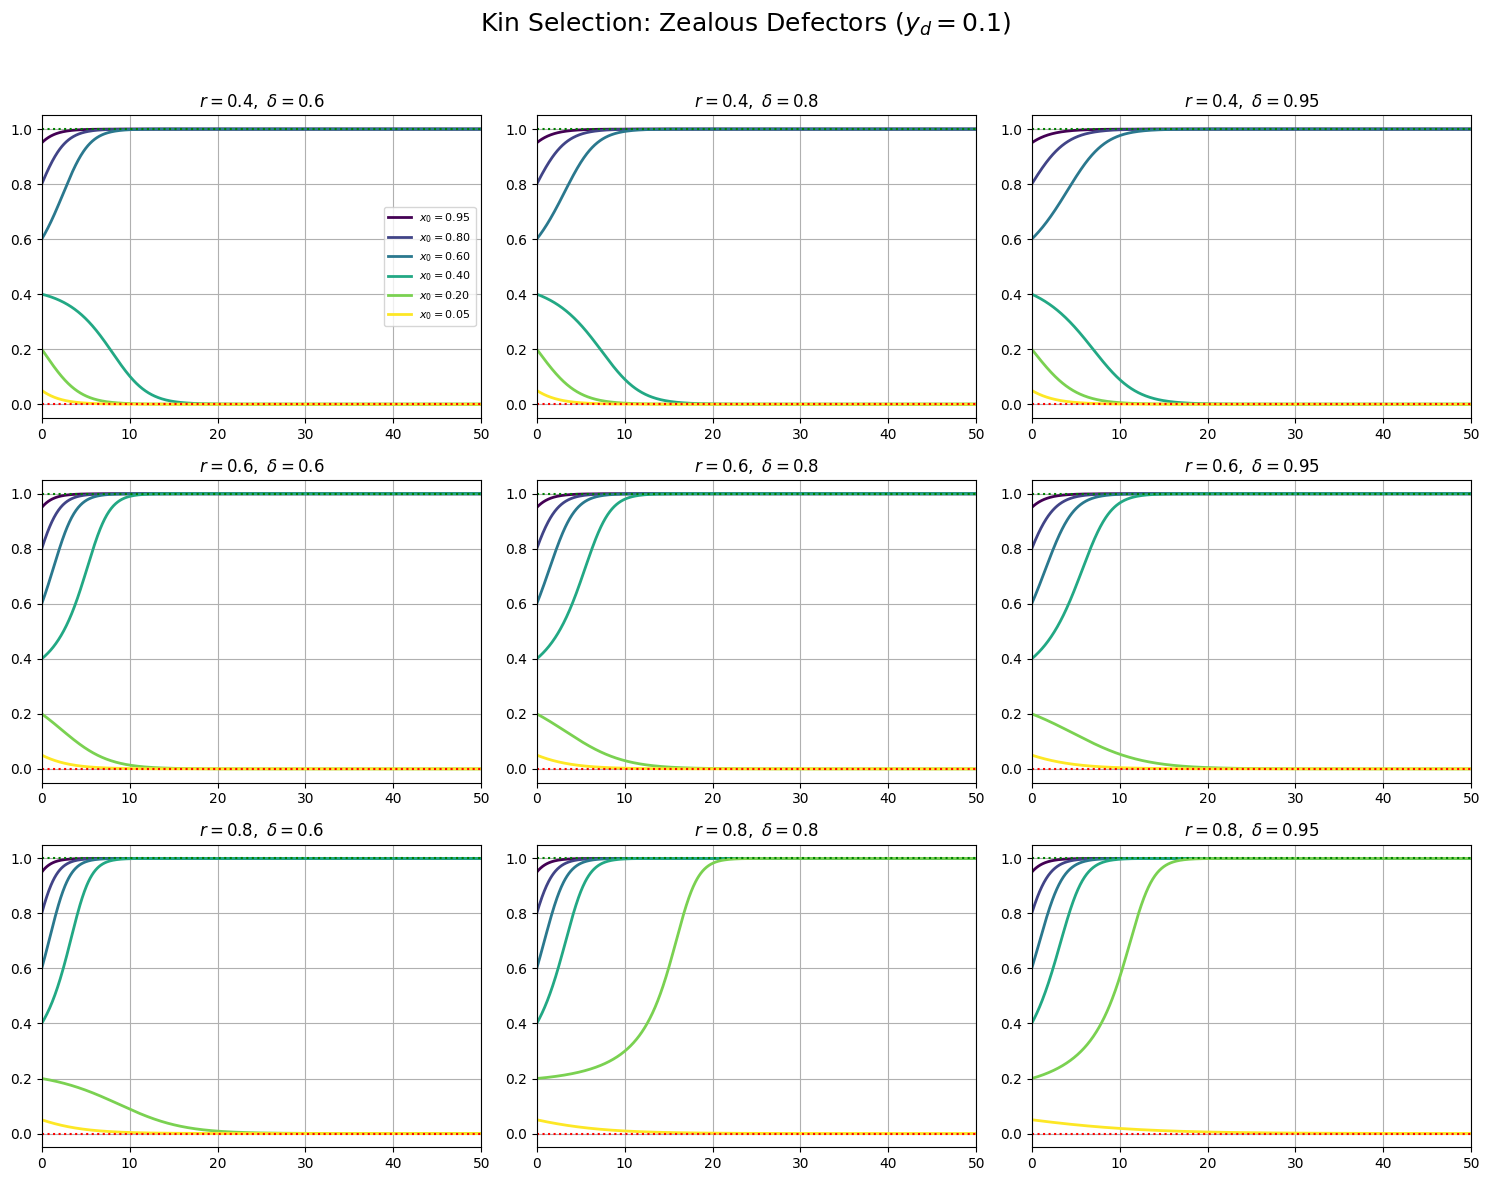

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================================
# STAG HUNT + KIN SELECTION
# STANDARD REPLICATOR DYNAMICS
#
# dx/dt = x(1-x)(πC-πD)
# ==========================================================

# ---------------- PARAMETERS ----------------
r_values = [0.4, 0.6, 0.8]
delta_values = [0.6, 0.8, 0.95]

yc = 0.10
yd = 0.10

x0_list = [0.95, 0.80, 0.60, 0.40, 0.20, 0.05]

tspan = (0,50)
t_eval = np.linspace(0,50,1000)

colors = plt.cm.viridis(np.linspace(0,1,len(x0_list)))

# ==========================================================
# ODE FUNCTIONS
# ==========================================================

def no_zealot(t,y,r,delta):

    x = y[0]

    R = 1
    S = (-1+r*delta)/(1+r)
    T = (delta-r)/(1+r)
    P = 0

    piC = x*R + (1-x)*S
    piD = x*T + (1-x)*P

    return [x*(1-x)*(piC-piD)]


def zealot_C(t,y,r,delta,yc):

    x = y[0]

    R = 1
    S = (-1+r*delta)/(1+r)
    T = (delta-r)/(1+r)
    P = 0

    piC = ((x+yc)*R + (1-x)*S)/(1+yc)
    piD = ((x+yc)*T + (1-x)*P)/(1+yc)

    return [x*(1-x)*(piC-piD)]


def zealot_D(t,y,r,delta,yd):

    x = y[0]

    R = 1
    S = (-1+r*delta)/(1+r)
    T = (delta-r)/(1+r)
    P = 0

    piC = (x*R + (1-x+yd)*S)/(1+yd)
    piD = (x*T + (1-x+yd)*P)/(1+yd)

    return [x*(1-x)*(piC-piD)]

# ==========================================================
# NO ZEALOTS
# ==========================================================

fig1, axes = plt.subplots(3,3,figsize=(15,12))
fig1.suptitle("Kin Selection: No Zealots",fontsize=18)

for i,r in enumerate(r_values):

    for j,delta in enumerate(delta_values):

        ax=axes[i,j]

        for k,x0 in enumerate(x0_list):

            sol=solve_ivp(
                no_zealot,
                tspan,
                [x0],
                args=(r,delta),
                t_eval=t_eval,
                rtol=1e-9,
                atol=1e-12
            )

            ax.plot(sol.t,sol.y[0],
                    color=colors[k],
                    lw=2,
                    label=f"$x_0={x0:.2f}$")

        ax.axhline(0,color='r',ls=':')
        ax.axhline(1,color='g',ls=':')

        ax.set_title(fr"$r={r},\ \delta={delta}$")
        ax.set_xlim(0,50)
        ax.set_ylim(-0.05,1.05)
        ax.grid(True)

        if i==0 and j==0:
            ax.legend(fontsize=8)

plt.tight_layout(rect=[0,0,1,0.96])

# ==========================================================
# ZEALOUS COOPERATORS
# ==========================================================

fig2, axes = plt.subplots(3,3,figsize=(15,12))
fig2.suptitle(
    f"Kin Selection: Zealous Cooperators ($y_c={yc}$)",
    fontsize=18
)

for i,r in enumerate(r_values):

    for j,delta in enumerate(delta_values):

        ax=axes[i,j]

        for k,x0 in enumerate(x0_list):

            sol=solve_ivp(
                zealot_C,
                tspan,
                [x0],
                args=(r,delta,yc),
                t_eval=t_eval,
                rtol=1e-9,
                atol=1e-12
            )

            ax.plot(sol.t,sol.y[0],
                    color=colors[k],
                    lw=2,
                    label=f"$x_0={x0:.2f}$")

        ax.axhline(0,color='r',ls=':')
        ax.axhline(1,color='g',ls=':')

        ax.set_title(fr"$r={r},\ \delta={delta}$")
        ax.set_xlim(0,50)
        ax.set_ylim(-0.05,1.05)
        ax.grid(True)

        if i==0 and j==0:
            ax.legend(fontsize=8)

plt.tight_layout(rect=[0,0,1,0.96])

# ==========================================================
# ZEALOUS DEFECTORS
# ==========================================================

fig3, axes = plt.subplots(3,3,figsize=(15,12))
fig3.suptitle(
    f"Kin Selection: Zealous Defectors ($y_d={yd}$)",
    fontsize=18
)

for i,r in enumerate(r_values):

    for j,delta in enumerate(delta_values):

        ax=axes[i,j]

        for k,x0 in enumerate(x0_list):

            sol=solve_ivp(
                zealot_D,
                tspan,
                [x0],
                args=(r,delta,yd),
                t_eval=t_eval,
                rtol=1e-9,
                atol=1e-12
            )

            ax.plot(sol.t,sol.y[0],
                    color=colors[k],
                    lw=2,
                    label=f"$x_0={x0:.2f}$")

        ax.axhline(0,color='r',ls=':')
        ax.axhline(1,color='g',ls=':')

        ax.set_title(fr"$r={r},\ \delta={delta}$")
        ax.set_xlim(0,50)
        ax.set_ylim(-0.05,1.05)
        ax.grid(True)

        if i==0 and j==0:
            ax.legend(fontsize=8)

plt.tight_layout(rect=[0,0,1,0.96])

plt.show()